### Supply Chain Analysis

## Project Objective

The objective of this project is to analyze supply chain data
to understand sales performance, inventory, manufacturing,
quality, shipping, transportation, and supplier operations.

The analysis will identify important business insights and
provide actionable recommendations for improving supply chain
operations and profitability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
#Load the CSV
df = pd.read_csv("supply_chain_data.csv")
df

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864


In [4]:
#Check first rows
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [5]:
#Check dataset size
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 100
Columns: 24


In [6]:
#Check column names
df.columns.tolist()

['Product type',
 'SKU',
 'Price',
 'Availability',
 'Number of products sold',
 'Revenue generated',
 'Customer demographics',
 'Stock levels',
 'Lead times',
 'Order quantities',
 'Shipping times',
 'Shipping carriers',
 'Shipping costs',
 'Supplier name',
 'Location',
 'Lead time',
 'Production volumes',
 'Manufacturing lead time',
 'Manufacturing costs',
 'Inspection results',
 'Defect rates',
 'Transportation modes',
 'Routes',
 'Costs']

In [7]:
#Check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    str    
 1   SKU                      100 non-null    str    
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    str    
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    str    
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    str    
 14  Location                 100 non-null 

In [8]:
#— Check missing values
df.isnull().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [9]:
#Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
#Statistical summary
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product type,100,3,skincare,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SKU,100,100,SKU0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,100.0,NaN,NaN,NaN,49.462461,31.168193,1.699976,19.597823,51.239831,77.198228,99.171329
Availability,100.0,NaN,NaN,NaN,48.4,30.743317,1.0,22.75,43.5,75.0,100.0
Number of products sold,100.0,NaN,NaN,NaN,460.99,303.780074,8.0,184.25,392.5,704.25,996.0
Revenue generated,100.0,NaN,NaN,NaN,5776.048187,2732.841744,1061.618523,2812.847151,6006.352023,8253.976921,9866.465458
Customer demographics,100,4,Unknown,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stock levels,100.0,NaN,NaN,NaN,47.77,31.369372,0.0,16.75,47.5,73.0,100.0
Lead times,100.0,NaN,NaN,NaN,15.96,8.785801,1.0,8.0,17.0,24.0,30.0
Order quantities,100.0,NaN,NaN,NaN,49.22,26.784429,1.0,26.0,52.0,71.25,96.0


In [11]:
#Find categorical columns
categorical_cols = df.select_dtypes(include="str").columns.tolist()

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['Product type', 'SKU', 'Customer demographics', 'Shipping carriers', 'Supplier name', 'Location', 'Inspection results', 'Transportation modes', 'Routes']


In [12]:
#Find numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

Numerical columns:
['Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping costs', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Defect rates', 'Costs']


In [13]:
#Check unique values of categorical columns
for col in categorical_cols:
    print("\n", col)
    print(df[col].nunique())


 Product type
3

 SKU
100

 Customer demographics
4

 Shipping carriers
3

 Supplier name
5

 Location
5

 Inspection results
3

 Transportation modes
4

 Routes
3


In [14]:
#Final basic check
df.shape

(100, 24)

### STEP 2 — DATA CLEANING

In [15]:
#Make a working copy
df_clean = df.copy()

In [16]:
#Remove accidental spaces from column names
df_clean.columns = df_clean.columns.str.strip()

In [17]:
#Check categorical values
for col in categorical_cols:
    print("\n", col)
    print(df_clean[col].value_counts())


 Product type
Product type
skincare     40
haircare     34
cosmetics    26
Name: count, dtype: int64

 SKU
SKU
SKU0     1
SKU1     1
SKU2     1
SKU3     1
SKU4     1
        ..
SKU95    1
SKU96    1
SKU97    1
SKU98    1
SKU99    1
Name: count, Length: 100, dtype: int64

 Customer demographics
Customer demographics
Unknown       31
Female        25
Non-binary    23
Male          21
Name: count, dtype: int64

 Shipping carriers
Shipping carriers
Carrier B    43
Carrier C    29
Carrier A    28
Name: count, dtype: int64

 Supplier name
Supplier name
Supplier 1    27
Supplier 2    22
Supplier 5    18
Supplier 4    18
Supplier 3    15
Name: count, dtype: int64

 Location
Location
Kolkata      25
Mumbai       22
Chennai      20
Bangalore    18
Delhi        15
Name: count, dtype: int64

 Inspection results
Inspection results
Pending    41
Fail       36
Pass       23
Name: count, dtype: int64

 Transportation modes
Transportation modes
Road    29
Rail    28
Air     26
Sea     17
Name: count, 

In [18]:
#Check numerical columns for impossible negative values
for col in numerical_cols:
    print(col, ":", (df_clean[col] < 0).sum())

Price : 0
Availability : 0
Number of products sold : 0
Revenue generated : 0
Stock levels : 0
Lead times : 0
Order quantities : 0
Shipping times : 0
Shipping costs : 0
Lead time : 0
Production volumes : 0
Manufacturing lead time : 0
Manufacturing costs : 0
Defect rates : 0
Costs : 0


In [19]:
#Final cleaning check
print("Shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicates:", df_clean.duplicated().sum())

Shape: (100, 24)
Missing values: 0
Duplicates: 0


### STEP 3 — SALES ANALYSIS

In [20]:
#Total products sold
total_products_sold = df_clean['Number of products sold'].sum()
print("Total Products Sold:", total_products_sold)

Total Products Sold: 46099


In [21]:
#Total revenue
total_revenue = df_clean['Revenue generated'].sum()
print("Total Revenue Generated:", round(total_revenue, 2))

Total Revenue Generated: 577604.82


In [22]:
#Sales and revenue by product type
product_sales = df_clean.groupby('Product type').agg(
    Products_Sold=('Number of products sold', 'sum'),
    Revenue=('Revenue generated', 'sum')
).sort_values('Revenue', ascending=False)

product_sales

,Products_Sold,Revenue
Product type,,
skincare,20731,241628.162133
haircare,13611,174455.390605
cosmetics,11757,161521.265999


In [23]:
#Customer demographics vs products sold
demographic_sales = df_clean.groupby(
    'Customer demographics'
)['Number of products sold'].sum().sort_values(ascending=False)

demographic_sales

Customer demographics
Unknown       15211
Female        12801
Non-binary    10580
Male           7507
Name: Number of products sold, dtype: int64

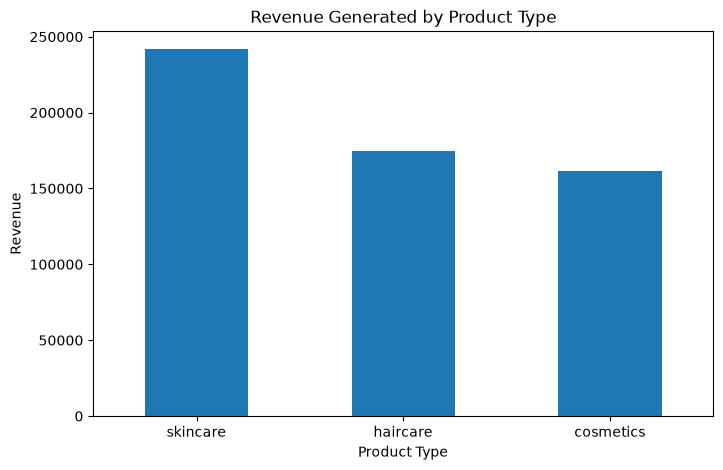

In [24]:
#Product type revenue chart
product_sales['Revenue'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Revenue Generated by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

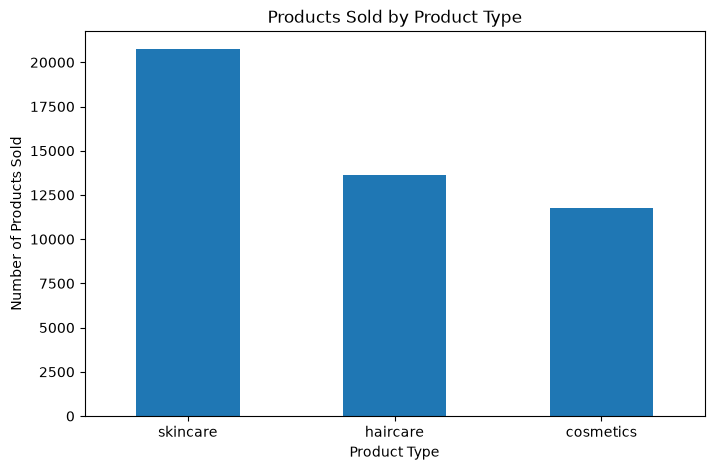

In [25]:
#Products sold by product type
product_sales['Products_Sold'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Products Sold by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Number of Products Sold')
plt.xticks(rotation=0)
plt.show()

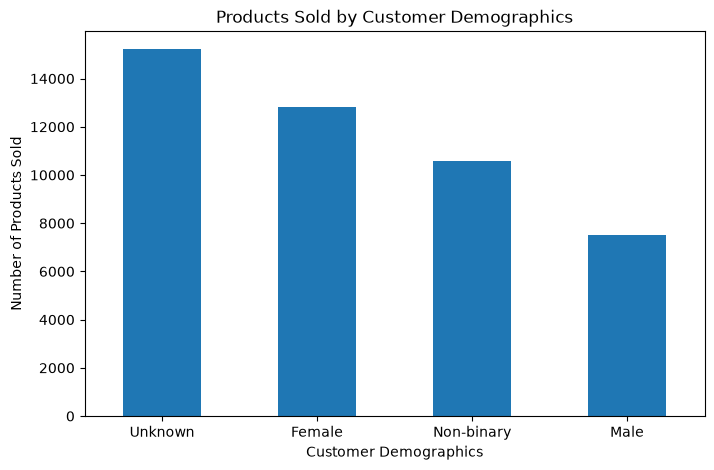

In [26]:
#Customer demographics chart
demographic_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Products Sold by Customer Demographics')
plt.xlabel('Customer Demographics')
plt.ylabel('Number of Products Sold')
plt.xticks(rotation=0)
plt.show()

In [27]:
#Stock availability analysis
stock_analysis = df_clean.groupby('Product type').agg(
    Average_Stock=('Stock levels', 'mean'),
    Average_Availability=('Availability', 'mean')
)

stock_analysis

,Average_Stock,Average_Availability
Product type,,
cosmetics,58.653846,51.230769
haircare,48.352941,43.264706
skincare,40.200000,50.925000


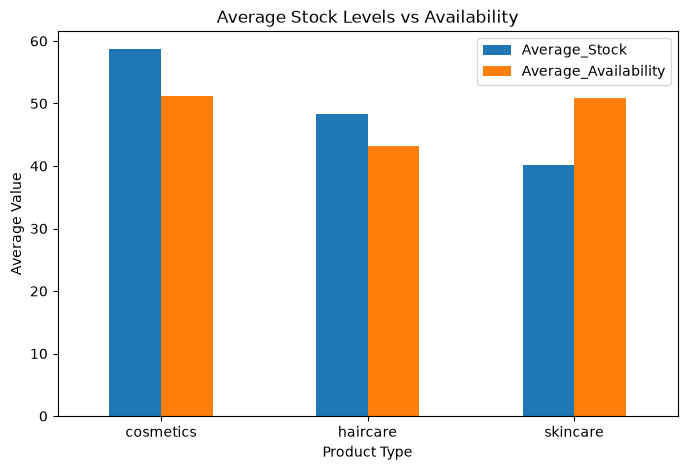

In [28]:
#Stock vs availability
stock_analysis.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Stock Levels vs Availability')
plt.xlabel('Product Type')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.show()

In [29]:
#Top 10 products by revenue
top_products = df_clean.nlargest(
    10, 'Revenue generated'
)[['SKU', 'Product type', 'Revenue generated']]

top_products

,SKU,Product type,Revenue generated
51,SKU51,haircare,9866.465458
38,SKU38,cosmetics,9692.318040
31,SKU31,skincare,9655.135103
90,SKU90,skincare,9592.633570
2,SKU2,haircare,9577.749626
32,SKU32,skincare,9571.550487
67,SKU67,skincare,9473.798033
88,SKU88,cosmetics,9444.742033
52,SKU52,skincare,9435.762609
18,SKU18,haircare,9364.673505


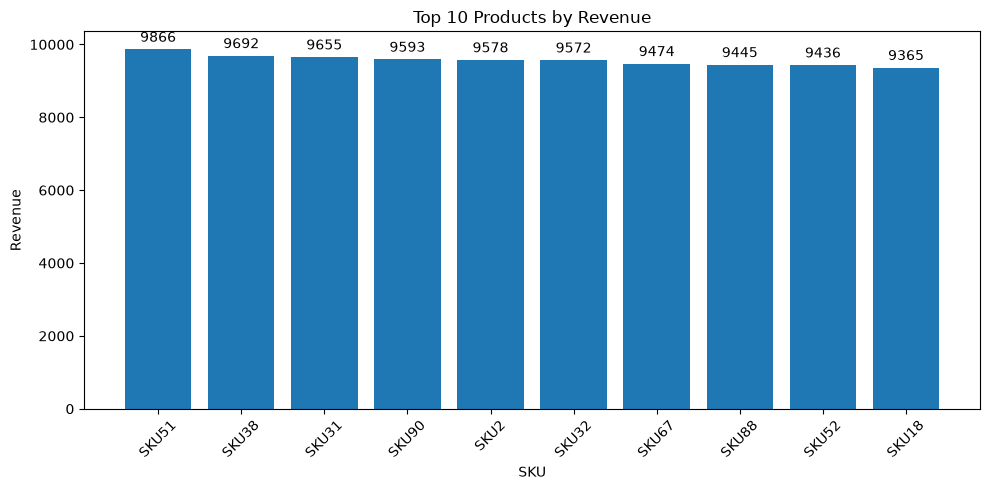

In [30]:
#Top 10 products chart
plt.figure(figsize=(10, 5))

ax = plt.gca()

bars = ax.bar(
    top_products['SKU'],
    top_products['Revenue generated']
)

ax.bar_label(
    bars,
    fmt='%.0f',
    padding=3
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('SKU')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### STEP 4 — OPERATIONAL ANALYSIS

In [31]:
#Production and order quantity by product type
operational_summary = df_clean.groupby('Product type').agg(
    Average_Order_Quantity=('Order quantities', 'mean'),
    Average_Production_Volume=('Production volumes', 'mean'),
    Average_Lead_Time=('Lead time', 'mean'),
    Average_Manufacturing_Lead_Time=('Manufacturing lead time', 'mean')
).round(2)

operational_summary

,Average_Order_Quantity,Average_Production_Volume,Average_Lead_Time,Average_Manufacturing_Lead_Time
Product type,,,,
cosmetics,51.65,479.27,13.54,13.31
haircare,43.53,586.97,18.71,17.06
skincare,52.48,609.15,18.00,13.78


In [32]:
#Manufacturing cost and price by product type
manufacturing_summary = df_clean.groupby('Product type').agg(
    Average_Price=('Price', 'mean'),
    Average_Manufacturing_Cost=('Manufacturing costs', 'mean')
).round(2)

manufacturing_summary

,Average_Price,Average_Manufacturing_Cost
Product type,,
cosmetics,57.36,43.05
haircare,46.01,48.46
skincare,47.26,48.99


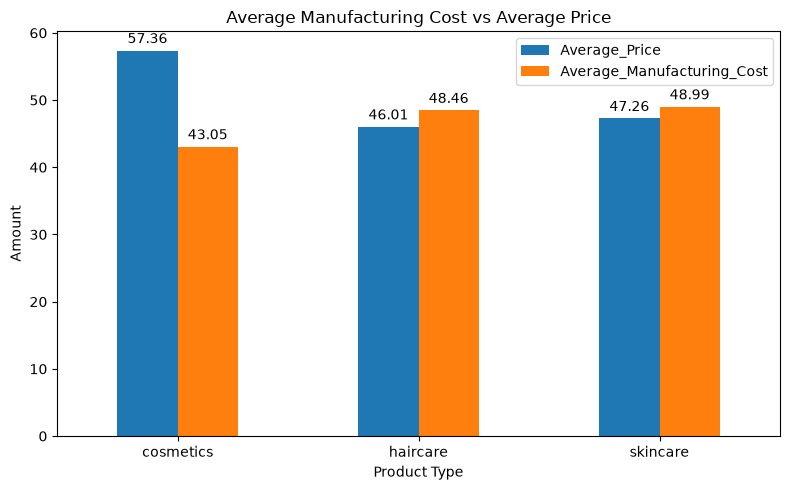

In [33]:
#Average manufacturing cost vs average price
ax = manufacturing_summary.plot(
    kind='bar',
    figsize=(8,5)
)

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
ax.bar_label(ax.containers[1], fmt='%.2f', padding=3)

plt.title('Average Manufacturing Cost vs Average Price')
plt.xlabel('Product Type')
plt.ylabel('Amount')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [34]:
#Inspection results
inspection_summary = df_clean['Inspection results'].value_counts()
inspection_summary

Inspection results
Pending    41
Fail       36
Pass       23
Name: count, dtype: int64

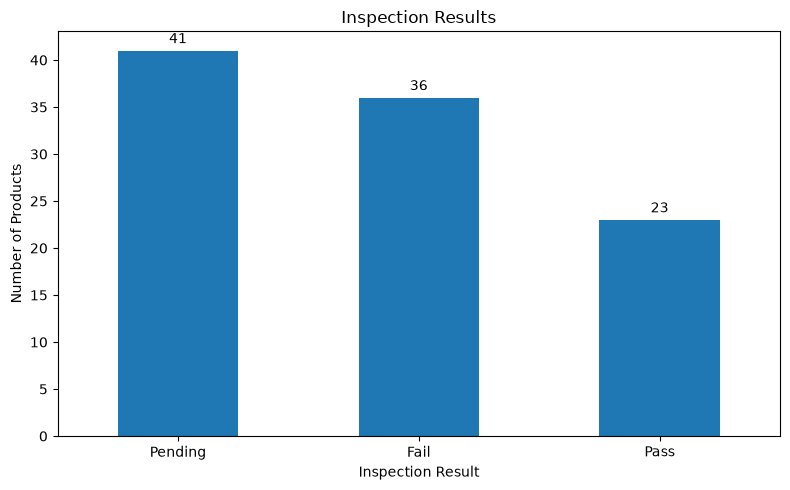

In [35]:
#inspection results chart
ax = inspection_summary.plot(
    kind='bar',
    figsize=(8,5)
)

ax.bar_label(ax.containers[0], padding=3)

plt.title('Inspection Results')
plt.xlabel('Inspection Result')
plt.ylabel('Number of Products')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [36]:
#Defect rate by product type
defect_summary = df_clean.groupby('Product type').agg(
    Average_Defect_Rate=('Defect rates', 'mean'),
    Average_Manufacturing_Lead_Time=('Manufacturing lead time', 'mean'),
    Average_Manufacturing_Cost=('Manufacturing costs', 'mean')
).round(2)

defect_summary

,Average_Defect_Rate,Average_Manufacturing_Lead_Time,Average_Manufacturing_Cost
Product type,,,
cosmetics,1.92,13.31,43.05
haircare,2.48,17.06,48.46
skincare,2.33,13.78,48.99


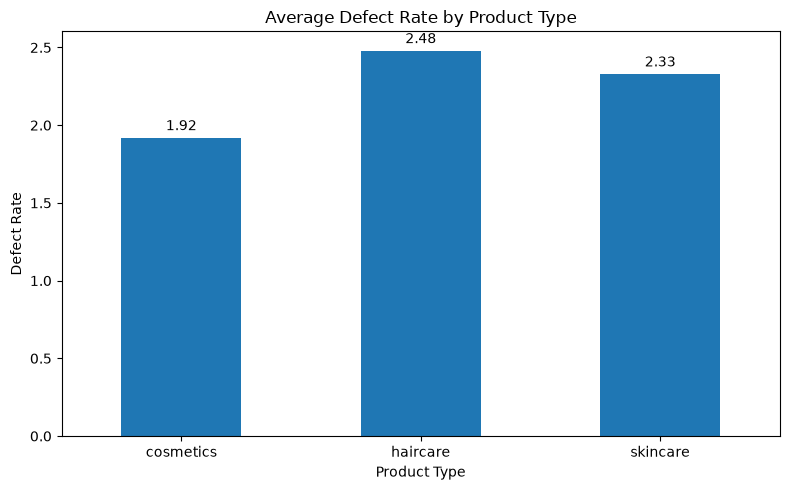

In [37]:
#Defect rate chart
ax = defect_summary['Average_Defect_Rate'].plot(
    kind='bar',
    figsize=(8,5)
)

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.title('Average Defect Rate by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Defect Rate')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [38]:
#Manufacturing lead time by product
lead_time_product = df_clean.groupby('Product type')[
    'Manufacturing lead time'
].mean().round(2)

lead_time_product

Product type
cosmetics    13.31
haircare     17.06
skincare     13.78
Name: Manufacturing lead time, dtype: float64

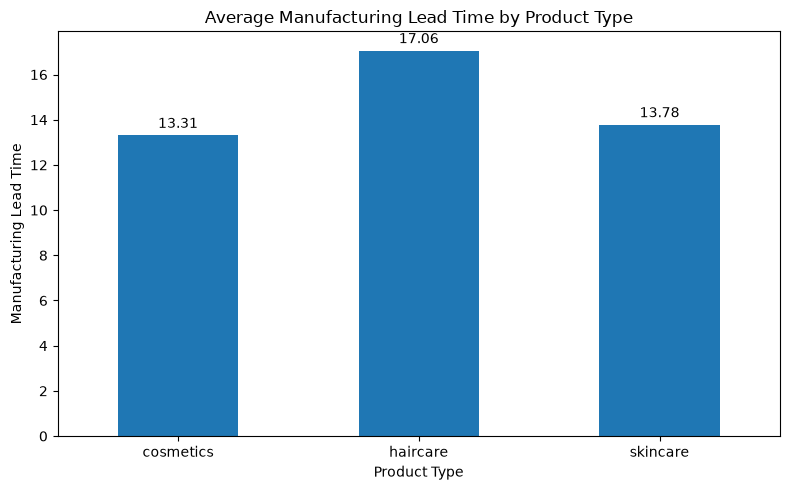

In [39]:
#Manufacturing lead time chart
ax = lead_time_product.plot(
    kind='bar',
    figsize=(8,5)
)

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.title('Average Manufacturing Lead Time by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Manufacturing Lead Time')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [40]:
#Overall operational KPIs
print("Average Order Quantity:",
      round(df_clean['Order quantities'].mean(), 2))

print("Average Production Volume:",
      round(df_clean['Production volumes'].mean(), 2))

print("Average Supplier Lead Time:",
      round(df_clean['Lead time'].mean(), 2))

print("Average Manufacturing Lead Time:",
      round(df_clean['Manufacturing lead time'].mean(), 2))

print("Average Manufacturing Cost:",
      round(df_clean['Manufacturing costs'].mean(), 2))

print("Average Defect Rate:",
      round(df_clean['Defect rates'].mean(), 2))

Average Order Quantity: 49.22
Average Production Volume: 567.84
Average Supplier Lead Time: 17.08
Average Manufacturing Lead Time: 14.77
Average Manufacturing Cost: 47.27
Average Defect Rate: 2.28


### STEP 5 — SHIPPING ANALYSIS

In [41]:
#Shipping summary by transportation mode
shipping_mode = df_clean.groupby('Transportation modes').agg(
    Average_Shipping_Time=('Shipping times', 'mean'),
    Average_Shipping_Cost=('Shipping costs', 'mean'),
    Average_Total_Cost=('Costs', 'mean')
).round(2)

shipping_mode

,Average_Shipping_Time,Average_Shipping_Cost,Average_Total_Cost
Transportation modes,,,
Air,5.12,6.02,561.71
Rail,6.57,5.47,541.75
Road,4.72,5.54,553.39
Sea,7.12,4.97,417.82


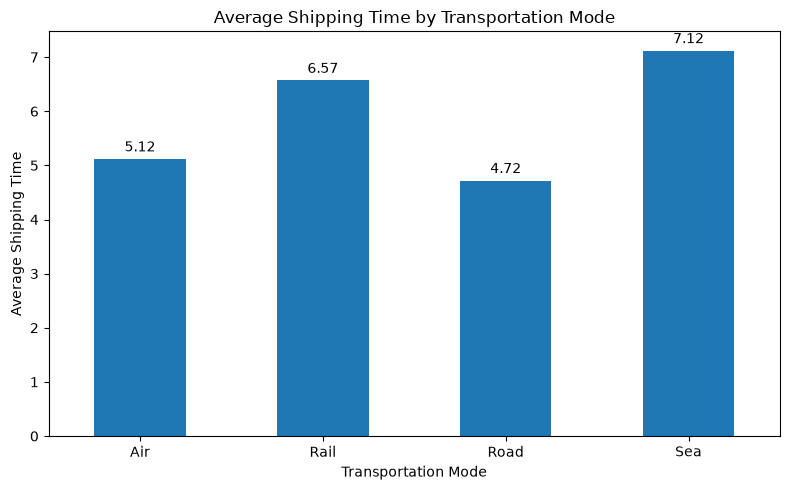

In [42]:
#Transportation mode vs shipping time
ax = shipping_mode['Average_Shipping_Time'].plot(
    kind='bar',
    figsize=(8,5)
)

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.title('Average Shipping Time by Transportation Mode')
plt.xlabel('Transportation Mode')
plt.ylabel('Average Shipping Time')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

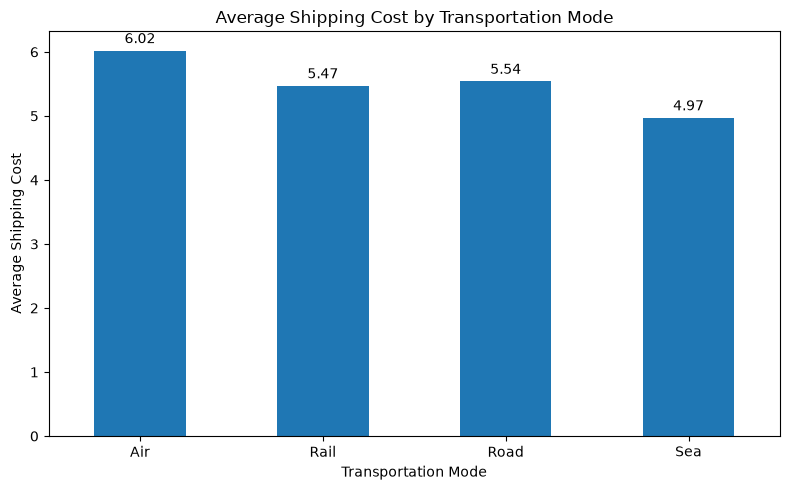

In [43]:
#Transportation mode vs shipping cost
ax = shipping_mode['Average_Shipping_Cost'].plot(
    kind='bar',
    figsize=(8,5)
)

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.title('Average Shipping Cost by Transportation Mode')
plt.xlabel('Transportation Mode')
plt.ylabel('Average Shipping Cost')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [44]:
#Route analysis
route_summary = df_clean.groupby('Routes').agg(
    Average_Shipping_Cost=('Shipping costs', 'mean'),
    Average_Shipping_Time=('Shipping times', 'mean'),
    Average_Total_Cost=('Costs', 'mean')
).round(2)

route_summary

,Average_Shipping_Cost,Average_Shipping_Time,Average_Total_Cost
Routes,,,
Route A,5.38,6.02,485.48
Route B,5.55,5.70,595.66
Route C,5.90,5.25,500.47


In [45]:
#Transportation modes vs routes with average cost
mode_route = df_clean.pivot_table(
    index='Routes',
    columns='Transportation modes',
    values='Costs',
    aggfunc='mean'
)

mode_route

Transportation modes,Air,Rail,Road,Sea
Routes,,,,
Route A,527.353405,485.050751,539.492010,335.680631
Route B,637.836861,637.037340,552.391165,564.338352
Route C,542.347752,456.936769,586.539277,341.782748


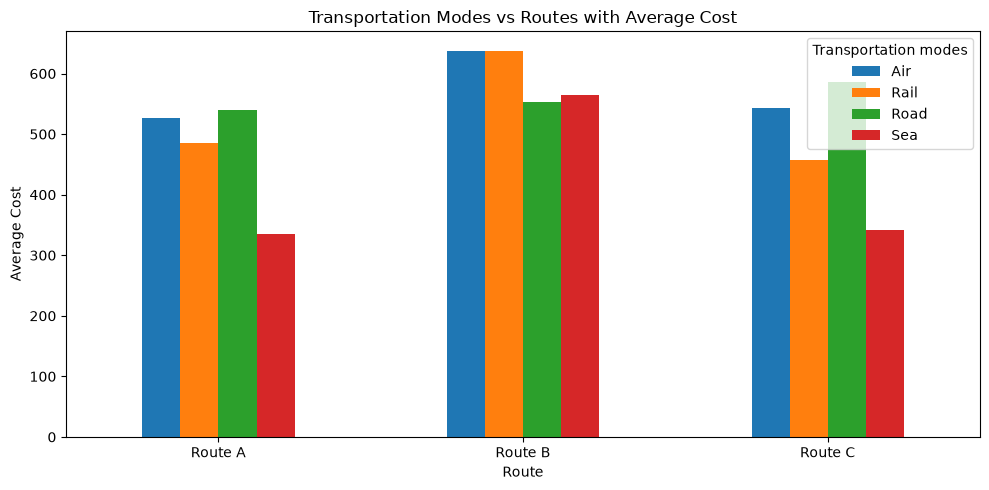

In [46]:
#Route and transportation cost chart
ax = mode_route.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Transportation Modes vs Routes with Average Cost')
plt.xlabel('Route')
plt.ylabel('Average Cost')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [47]:
#Shipping carrier analysis
carrier_summary = df_clean.groupby('Shipping carriers').agg(
    Average_Shipping_Time=('Shipping times', 'mean'),
    Average_Shipping_Cost=('Shipping costs', 'mean')
).round(2)

carrier_summary

,Average_Shipping_Time,Average_Shipping_Cost
Shipping carriers,,
Carrier A,6.14,5.55
Carrier B,5.30,5.51
Carrier C,6.03,5.60


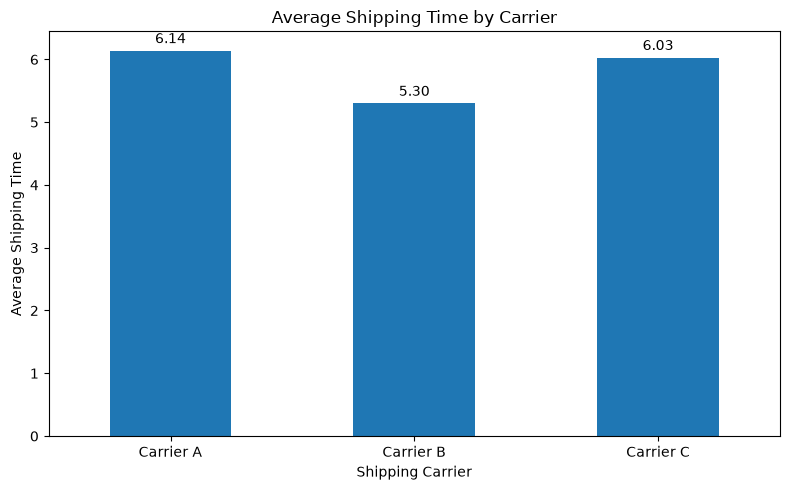

In [48]:
#Carrier vs shipping time
ax = carrier_summary['Average_Shipping_Time'].plot(
    kind='bar',
    figsize=(8,5)
)

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.title('Average Shipping Time by Carrier')
plt.xlabel('Shipping Carrier')
plt.ylabel('Average Shipping Time')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [49]:
#Overall shipping KPIs
print("Average Shipping Time:",
      round(df_clean['Shipping times'].mean(), 2))

print("Average Shipping Cost:",
      round(df_clean['Shipping costs'].mean(), 2))

print("Average Total Cost:",
      round(df_clean['Costs'].mean(), 2))

Average Shipping Time: 5.75
Average Shipping Cost: 5.55
Average Total Cost: 529.25


#Final shipping comparison
shipping_comparison = df_clean.groupby(
    ['Transportation modes', 'Shipping carriers']
).agg(
    Average_Shipping_Time=('Shipping times', 'mean'),
    Average_Shipping_Cost=('Shipping costs', 'mean')
).round(2)

shipping_comparison

### STEP 6 — FINAL INSIGHTS & BUSINESS RECOMMENDATIONS

In [51]:
#Product performance summary
product_performance = df_clean.groupby('Product type').agg(
    Products_Sold=('Number of products sold', 'sum'),
    Revenue=('Revenue generated', 'sum'),
    Average_Price=('Price', 'mean'),
    Average_Stock=('Stock levels', 'mean'),
    Average_Defect_Rate=('Defect rates', 'mean'),
    Average_Manufacturing_Cost=('Manufacturing costs', 'mean')
).round(2)

product_performance

,Products_Sold,Revenue,Average_Price,Average_Stock,Average_Defect_Rate,Average_Manufacturing_Cost
Product type,,,,,,
cosmetics,11757,161521.27,57.36,58.65,1.92,43.05
haircare,13611,174455.39,46.01,48.35,2.48,48.46
skincare,20731,241628.16,47.26,40.20,2.33,48.99


In [52]:
#Calculate revenue per product sold
product_performance['Revenue_per_Product'] = (
    product_performance['Revenue'] /
    product_performance['Products_Sold']
).round(2)

product_performance

,Products_Sold,Revenue,Average_Price,Average_Stock,Average_Defect_Rate,Average_Manufacturing_Cost,Revenue_per_Product
Product type,,,,,,,
cosmetics,11757,161521.27,57.36,58.65,1.92,43.05,13.74
haircare,13611,174455.39,46.01,48.35,2.48,48.46,12.82
skincare,20731,241628.16,47.26,40.20,2.33,48.99,11.66


In [53]:
#Calculate revenue per product sold
product_performance['Revenue_per_Product'] = (
    product_performance['Revenue'] /
    product_performance['Products_Sold']
).round(2)

product_performance

,Products_Sold,Revenue,Average_Price,Average_Stock,Average_Defect_Rate,Average_Manufacturing_Cost,Revenue_per_Product
Product type,,,,,,,
cosmetics,11757,161521.27,57.36,58.65,1.92,43.05,13.74
haircare,13611,174455.39,46.01,48.35,2.48,48.46,12.82
skincare,20731,241628.16,47.26,40.20,2.33,48.99,11.66


In [54]:
#Identify highest-revenue product type
highest_revenue_product = product_performance['Revenue'].idxmax()

print("Highest Revenue Product Type:", highest_revenue_product)
print(
    "Revenue:",
    round(product_performance.loc[highest_revenue_product, 'Revenue'], 2)
)

Highest Revenue Product Type: skincare
Revenue: 241628.16


In [55]:
#Identify highest-selling product type
highest_sales_product = product_performance['Products_Sold'].idxmax()

print("Highest Selling Product Type:", highest_sales_product)
print(
    "Products Sold:",
    product_performance.loc[highest_sales_product, 'Products_Sold']
)

Highest Selling Product Type: skincare
Products Sold: 20731


In [56]:
#Highest defect product type
highest_defect_product = product_performance['Average_Defect_Rate'].idxmax()

print("Highest Average Defect Rate:", highest_defect_product)
print(
    "Defect Rate:",
    round(
        product_performance.loc[
            highest_defect_product,
            'Average_Defect_Rate'
        ],
        2
    )
)

Highest Average Defect Rate: haircare
Defect Rate: 2.48


In [57]:
#Shipping performance summary
shipping_performance = df_clean.groupby(
    'Transportation modes'
).agg(
    Average_Shipping_Time=('Shipping times', 'mean'),
    Average_Shipping_Cost=('Shipping costs', 'mean')
).round(2)

shipping_performance

,Average_Shipping_Time,Average_Shipping_Cost
Transportation modes,,
Air,5.12,6.02
Rail,6.57,5.47
Road,4.72,5.54
Sea,7.12,4.97


In [58]:
#Supplier performance
supplier_performance = df_clean.groupby('Supplier name').agg(
    Average_Lead_Time=('Lead time', 'mean'),
    Average_Manufacturing_Cost=('Manufacturing costs', 'mean'),
    Average_Defect_Rate=('Defect rates', 'mean')
).round(2)

supplier_performance

,Average_Lead_Time,Average_Manufacturing_Cost,Average_Defect_Rate
Supplier name,,,
Supplier 1,14.78,45.25,1.80
Supplier 2,18.55,41.62,2.36
Supplier 3,20.13,43.63,2.47
Supplier 4,15.22,62.71,2.34
Supplier 5,18.06,44.77,2.67


In [59]:
#Location performance
location_performance = df_clean.groupby('Location').agg(
    Products_Sold=('Number of products sold', 'sum'),
    Revenue=('Revenue generated', 'sum'),
    Average_Shipping_Cost=('Shipping costs', 'mean')
).round(2)

location_performance

,Products_Sold,Revenue,Average_Shipping_Cost
Location,,,
Bangalore,5420,102601.72,5.75
Chennai,8768,119142.82,4.69
Delhi,9715,81027.70,5.07
Kolkata,12770,137077.55,5.76
Mumbai,9426,137755.03,6.25


In [60]:
#Create final KPI summary
final_kpis = {
    'Total Products Sold': df_clean['Number of products sold'].sum(),
    'Total Revenue': round(df_clean['Revenue generated'].sum(), 2),
    'Average Shipping Time': round(df_clean['Shipping times'].mean(), 2),
    'Average Shipping Cost': round(df_clean['Shipping costs'].mean(), 2),
    'Average Manufacturing Cost': round(df_clean['Manufacturing costs'].mean(), 2),
    'Average Defect Rate': round(df_clean['Defect rates'].mean(), 2)
}

final_kpis

{'Total Products Sold': np.int64(46099),
 'Total Revenue': np.float64(577604.82),
 'Average Shipping Time': np.float64(5.75),
 'Average Shipping Cost': np.float64(5.55),
 'Average Manufacturing Cost': np.float64(47.27),
 'Average Defect Rate': np.float64(2.28)}

In [63]:
#Average Defect Rate, Manufacturing Lead Time & Manufacturing Cost by Product
product_operations = df_clean.groupby('Product type').agg(
    Average_Defect_Rate=('Defect rates', 'mean'),
    Average_Manufacturing_Lead_Time=('Manufacturing lead time', 'mean'),
    Average_Manufacturing_Cost=('Manufacturing costs', 'mean')
).round(2)

product_operations

,Average_Defect_Rate,Average_Manufacturing_Lead_Time,Average_Manufacturing_Cost
Product type,,,
cosmetics,1.92,13.31,43.05
haircare,2.48,17.06,48.46
skincare,2.33,13.78,48.99


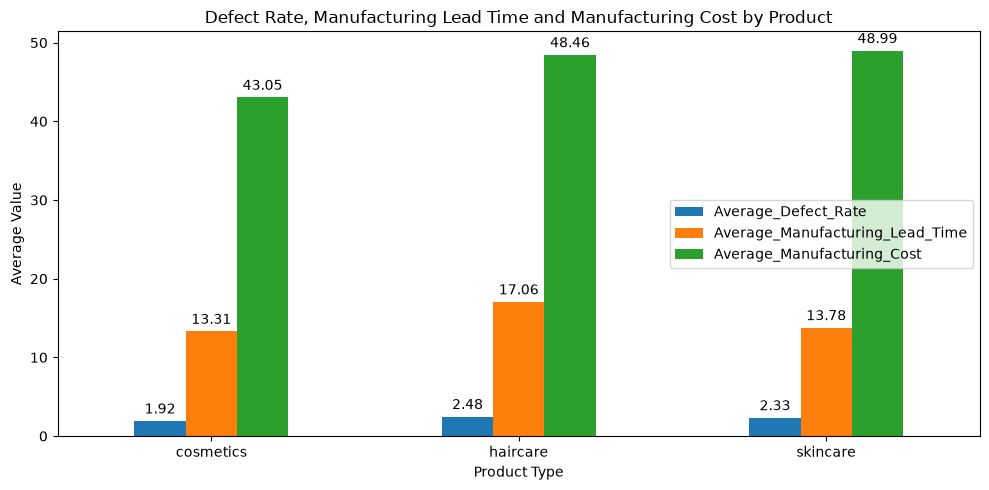

In [64]:
ax = product_operations.plot(
    kind='bar',
    figsize=(10, 5)
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title('Defect Rate, Manufacturing Lead Time and Manufacturing Cost by Product')
plt.xlabel('Product Type')
plt.ylabel('Average Value')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [65]:
#Customer Demographics vs Number of Products Sold by Product Type
demographic_product = df_clean.pivot_table(
    index='Product type',
    columns='Customer demographics',
    values='Number of products sold',
    aggfunc='sum'
)

demographic_product

Customer demographics,Female,Male,Non-binary,Unknown
Product type,,,,
cosmetics,4012,2304,2607,2834
haircare,936,2292,2820,7563
skincare,7853,2911,5153,4814


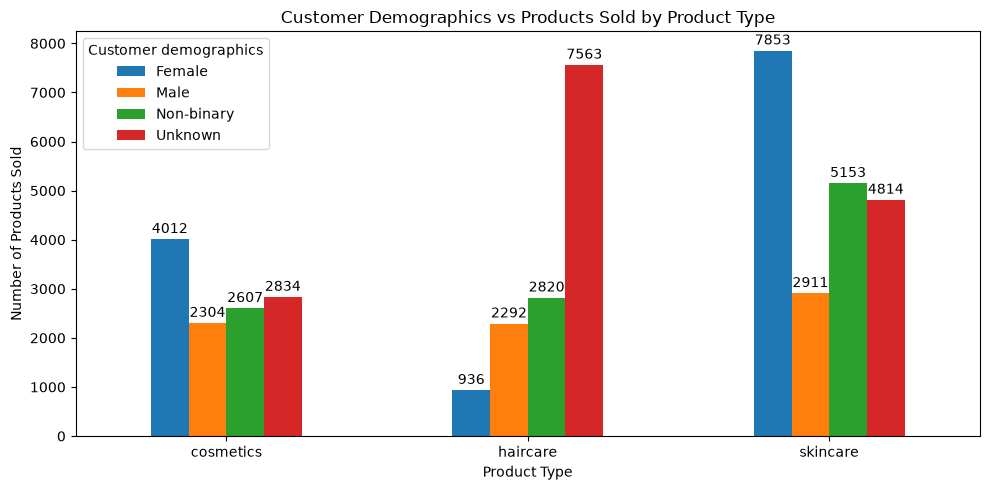

In [66]:
ax = demographic_product.plot(
    kind='bar',
    figsize=(10, 5)
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=2)

plt.title('Customer Demographics vs Products Sold by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Number of Products Sold')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [67]:
#Defect Rate vs Inspection Rate by Product Type
inspection_product = pd.crosstab(
    df_clean['Product type'],
    df_clean['Inspection results'],
    normalize='index'
).mul(100).round(2)

inspection_product

Inspection results,Fail,Pass,Pending
Product type,,,
cosmetics,38.46,23.08,38.46
haircare,38.24,17.65,44.12
skincare,32.50,27.50,40.00


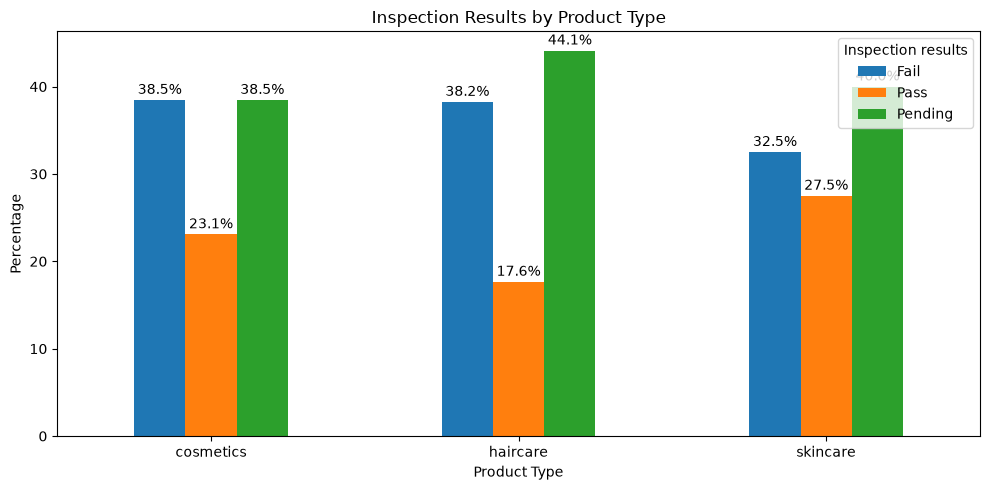

In [68]:
ax = inspection_product.plot(
    kind='bar',
    figsize=(10, 5)
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2)

plt.title('Inspection Results by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

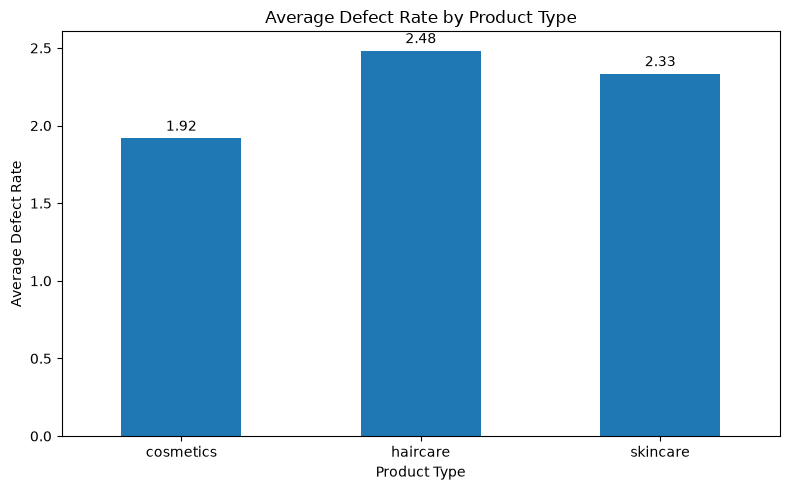

In [69]:
ax = df_clean.groupby('Product type')['Defect rates'].mean().plot(
    kind='bar',
    figsize=(8, 5)
)

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.title('Average Defect Rate by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Average Defect Rate')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [70]:
#Transportation Modes & Shipping Carriers with Average Shipping Time
mode_carrier_time = df_clean.pivot_table(
    index='Transportation modes',
    columns='Shipping carriers',
    values='Shipping times',
    aggfunc='mean'
).round(2)

mode_carrier_time

Shipping carriers,Carrier A,Carrier B,Carrier C
Transportation modes,,,
Air,5.60,4.21,6.57
Rail,7.43,6.33,6.17
Road,5.18,4.91,3.71
Sea,7.00,6.67,7.33


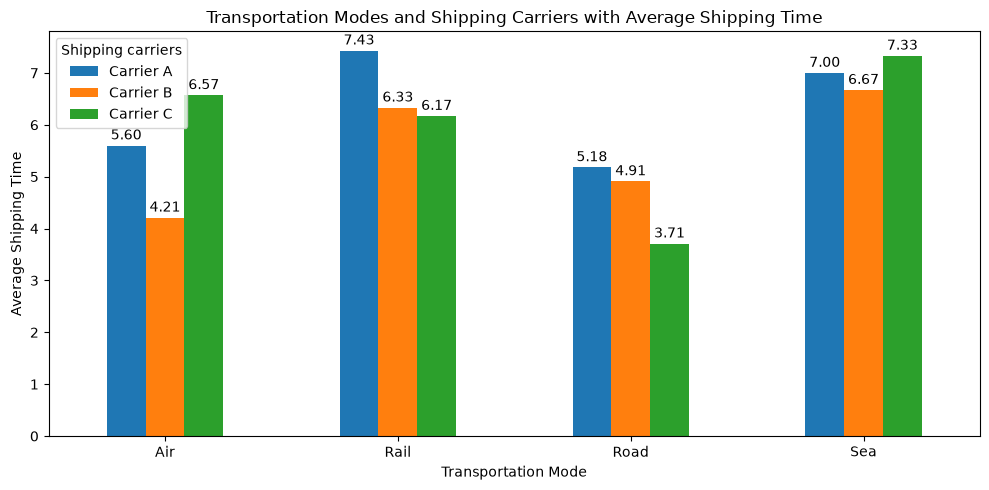

In [71]:
ax = mode_carrier_time.plot(
    kind='bar',
    figsize=(10, 5)
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2)

plt.title('Transportation Modes and Shipping Carriers with Average Shipping Time')
plt.xlabel('Transportation Mode')
plt.ylabel('Average Shipping Time')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [72]:
df_clean.to_csv(
    'supply_chain_cleaned.csv',
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [73]:
print("Project analysis completed!")
print("Dataset shape:", df_clean.shape)
print("Columns:", len(df_clean.columns))

Project analysis completed!
Dataset shape: (100, 24)
Columns: 24
